<a href="https://colab.research.google.com/github/ankit0318/machine-learning-mini-projects0/blob/main/01-supervised-learning/02-logistic-regression/placement_prediction/placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [38]:
df=pd.read_csv("placement_data.csv")
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [40]:
df.isnull().sum()


,0
cgpa,5
iq,0
placement,0


In [41]:
df['cgpa'].describe()

,cgpa
count,95
unique,39
top,"4,9"
freq,6


In [42]:
df['cgpa']=df['cgpa'].str.replace(',','.').astype('float')

In [43]:
df.head()
df['cgpa'].describe()
df['cgpa'].fillna(df['cgpa'].mean(),inplace=True)

/tmp/ipykernel_1680/2919089543.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cgpa'].fillna(df['cgpa'].mean(),inplace=True)


In [44]:
df['cgpa'].head()
df['cgpa'].describe()

,cgpa
count,100.000000
mean,5.988421
std,1.127513
min,3.300000
25%,5.075000
50%,6.000000
75%,6.825000
max,8.500000


In [45]:
df['placement']=df['placement'].map({'Yes':1,'No':0})
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


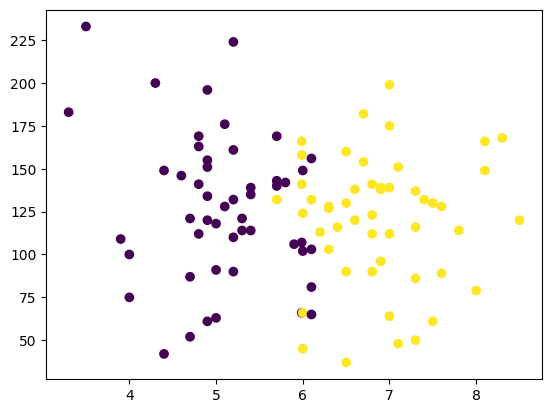

In [47]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [55]:
x=df.iloc[:,:2]
y=df.iloc[:,-1]





,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [64]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)


In [68]:
x_train


array([[-8.70670998e-01, -1.32557356e-01],
       [ 1.03559306e-02, -5.26942878e-01],
       [-7.82568305e-01,  1.29709016e+00],
       [ 1.15569094e+00, -9.21328401e-01],
       [-1.04687638e+00, -2.80451927e-01],
       [ 4.50869395e-01,  1.63231786e-01],
       [ 6.27074781e-01,  1.44498473e+00],
       [ 1.86051248e+00,  6.31564593e-01],
       [-9.58773691e-01,  2.61828166e-01],
       [-8.70670998e-01, -1.48825759e+00],
       [ 4.50869395e-01, -2.12913406e+00],
       [ 1.33189632e+00, -1.53755578e+00],
       [ 9.84586234e-02,  8.04108259e-01],
       [-7.82568305e-01,  1.13933595e-01],
       [ 7.15177473e-01,  4.34371832e-01],
       [ 6.27074781e-01,  7.54810069e-01],
       [-9.58773691e-01, -1.53755578e+00],
       [ 1.54566128e-04, -1.41431030e+00],
       [ 1.41999902e+00,  1.13933595e-01],
       [ 1.03559306e-02, -1.41431030e+00],
       [ 4.50869395e-01,  9.02704640e-01],
       [ 1.54566128e-04,  4.34371832e-01],
       [ 1.54566128e-04,  8.53406450e-01],
       [-6.

In [66]:
x_test=scalar.transform(x_test)

In [67]:
x_test

array([[ 1.86051248,  1.05059921],
       [-0.16584946,  0.45902093],
       [ 0.09845862, -1.04457388],
       [-0.60636292, -0.23115374],
       [-0.69446561, -0.32975012],
       [-0.95877369,  0.68086278],
       [-0.95877369,  0.77945916],
       [ 0.89138286, -1.46360849],
       [-0.25395215,  0.21252998],
       [ 0.80328017,  0.38507364]])

In [71]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(x_train,y_train)


LogisticRegression()

In [74]:
y_pred=clf.predict(x_test)

In [93]:
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1])

In [75]:
y_test

,placement
65,1
4,0
78,0
46,0
92,0
89,0
76,0
64,1
87,1
60,1


In [76]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8

<Axes: >

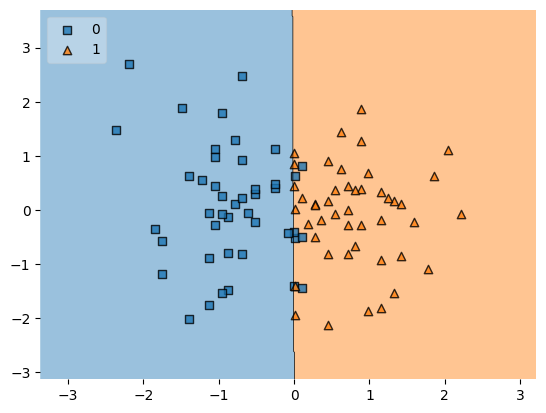

In [78]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [80]:
import pickle
pickle.dump(clf,open('placement_model.pkl','wb'))

In [92]:
clf=pickle.load(open('placement_model.pkl','rb'))
new_student=[6,80]
new_student_scaled=scalar.transform([new_student])
clf.predict(new_student_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])